In [2]:
import numpy as np
import matplotlib.pyplot as plt
from games.blotto import Blotto
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM

# Blotto

Juego de **suma cero** con 2 agentes, donde cada jugador distribuye **S soldados** entre **N campos de batalla**. Gana cada campo quien envíe más soldados; gana el juego quien gane más campos.

Configuración: `S = 6` soldados, `N = 3` campos de batalla.

Las estrategias (puras) son todas las distribuciones ordenadas no decrecientes:

| Índice | Distribución | Interpretación |
|--------|-------------|----------------|
| m₀ | (1, 1, 4) | foco en un campo de batalla|
| m₁ | (1, 2, 3) | Distribución escalonada |
| m₂ | (2, 2, 2) | Distribución uniforme |

La función de utilidad: `u₀ = +1` si agent_0 gana más campos, `-1` si pierde, `0` en empate.

In [3]:
g = Blotto(S=6, N=3)

In [4]:
g.reset()

In [5]:
g.agents

['agent_0', 'agent_1']

In [6]:
g._moves


[[1, 1, 4], [1, 2, 3], [2, 2, 2]]

In [7]:
# Variables globales usadas en todo el notebook
move_labels = [str(tuple(m)) for m in g._moves]
R = g._R
move_labels

['(1, 1, 4)', '(1, 2, 3)', '(2, 2, 2)']

## Análisis

### Estrategias dominantes

| Relación | Tipo |
|----------|------|
| m₂ = (2,2,2) **débilmente domina** a m₀ = (1,1,4) | m₂ ≥ m₀ en todos los escenarios; estrictamente mejor cuando el oponente juega m₀ |


**Conclusión de dominancia:**
- m₂ = (2,2,2) es la única estrategia **débilmente dominante**.
- m₀ = (1,1,4) es la única estrategia **débilmente dominada** (por m₂).
- m₁ = (1,2,3) junto con m₂(ambas empatan) forman el soporte de los equilibrios de Nash.
- **No existe estrategia estrictamente dominante.**

### Equilibrios de Nash

Eliminando m₀ por débilmente dominada, m₁ y m₂ dan **siempre utilidad 0** entre sí. Cualquier combinación de m₁ y m₂ es un equilibrio de Nash:

| agent_0 \ agent_1 | m₁ = (1,2,3) | m₂ = (2,2,2) |
|-------------------|:---:|:---:|
| **m₁ = (1,2,3)** | EN (0, 0) | EN (0, 0) |
| **m₂ = (2,2,2)** | EN (0, 0) | EN (0, 0) |

A diferencia de Matching Pennies, este juego admite equilibrios en estrategias puras. Los algoritmos deberían converger a eliminar m₀ y concentrar masa en m₁ y/o m₂.

In [8]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna las políticas finales."""
    game.reset()
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        game.step(actions)
    return {a: agents[a].policy() for a in game.agents}


def track_convergence(game, agents, checkpoints):
    """Registra el vector de política completo en cada checkpoint.
    Retorna {agent: {action_idx: [prob_en_cada_checkpoint]}}."""
    game.reset()
    n_actions = game._num_actions
    history = {a: {i: [] for i in range(n_actions)} for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            for i, p in enumerate(agents[a].policy()):
                history[a][i].append(p)
    return history


def plot_convergence(history, checkpoints, title, game):
    """Un subplot por agente; una línea por estrategia pura."""
    labels = [str(tuple(m)) for m in game._moves]
    colors = ['#e74c3c', '#2ecc71', '#3498db']
    fig, axes = plt.subplots(1, len(game.agents),
                             figsize=(7 * len(game.agents), 4), sharey=True)
    for ax, agent in zip(axes, game.agents):
        for i, label in enumerate(labels):
            ax.plot(checkpoints, history[agent][i],
                    marker='o', label=label, color=colors[i])
        ax.set_xscale('log')
        ax.set_xlabel('Rondas (escala log)')
        ax.set_ylabel('Probabilidad de estrategia')
        ax.set_title(agent)
        ax.legend(title='Estrategia')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

Para cada experimento se muestran las políticas aprendidas (probabilidad de cada estrategia) y la estrategia con mayor probabilidad (argmax).

### Regret Matching vs Regret Matching

In [9]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(1.0)},
 'agent_1': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(1.0)}}

In [10]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [2, 2, 2]}

### Regret Matching vs Random Agent

In [11]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(1.0)},
 'agent_1': {'(1, 1, 4)': np.float64(0.333),
  '(1, 2, 3)': np.float64(0.333),
  '(2, 2, 2)': np.float64(0.333)}}

In [12]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 1, 4]}

### Fictitious Play vs Fictitious Play

In [13]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(0.999)},
 'agent_1': {'(1, 1, 4)': np.float64(0.0),
  '(1, 2, 3)': np.float64(0.001),
  '(2, 2, 2)': np.float64(0.999)}}

In [14]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [2, 2, 2]}

### Fictitious Play vs Random Agent

In [15]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.001),
  '(1, 2, 3)': np.float64(0.0),
  '(2, 2, 2)': np.float64(0.999)},
 'agent_1': {'(1, 1, 4)': np.float64(0.333),
  '(1, 2, 3)': np.float64(0.333),
  '(2, 2, 2)': np.float64(0.333)}}

In [16]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 1, 4]}

### IQL vs Random Agent

In [17]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.047),
  '(1, 2, 3)': np.float64(0.172),
  '(2, 2, 2)': np.float64(0.781)},
 'agent_1': {'(1, 1, 4)': np.float64(0.333),
  '(1, 2, 3)': np.float64(0.333),
  '(2, 2, 2)': np.float64(0.333)}}

In [18]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 1, 4]}

### IQL vs IQL

In [19]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.222),
  '(1, 2, 3)': np.float64(0.379),
  '(2, 2, 2)': np.float64(0.399)},
 'agent_1': {'(1, 1, 4)': np.float64(0.233),
  '(1, 2, 3)': np.float64(0.384),
  '(2, 2, 2)': np.float64(0.383)}}

In [20]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [1, 2, 3]}

### IQL vs Joint Action Learning AM

In [21]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.201),
  '(1, 2, 3)': np.float64(0.392),
  '(2, 2, 2)': np.float64(0.408)},
 'agent_1': {'(1, 1, 4)': np.float64(0.268),
  '(1, 2, 3)': np.float64(0.364),
  '(2, 2, 2)': np.float64(0.368)}}

In [22]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [2, 2, 2]}

### Joint Action Learning AM vs Joint Action Learning AM

In [23]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
policies = play_game(g, agents)
{a: dict(zip(move_labels, policies[a].round(3))) for a in g.agents}

{'agent_0': {'(1, 1, 4)': np.float64(0.194),
  '(1, 2, 3)': np.float64(0.403),
  '(2, 2, 2)': np.float64(0.403)},
 'agent_1': {'(1, 1, 4)': np.float64(0.216),
  '(1, 2, 3)': np.float64(0.392),
  '(2, 2, 2)': np.float64(0.392)}}

In [24]:
# Estrategia más probable
{a: g._moves[np.argmax(policies[a])] for a in g.agents}

{'agent_0': [2, 2, 2], 'agent_1': [2, 2, 2]}

## Análisis de Convergencia

Se registra la probabilidad de cada estrategia pura a lo largo del tiempo. Según el análisis teórico esperamos:
- **P(m₀=(1,1,4)) → 0**: es débilmente dominada, debe desaparecer.
- **P(m₁=(1,2,3)) + P(m₂=(2,2,2)) → 1**: los jugadores convergen a la región de Nash.

In [25]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

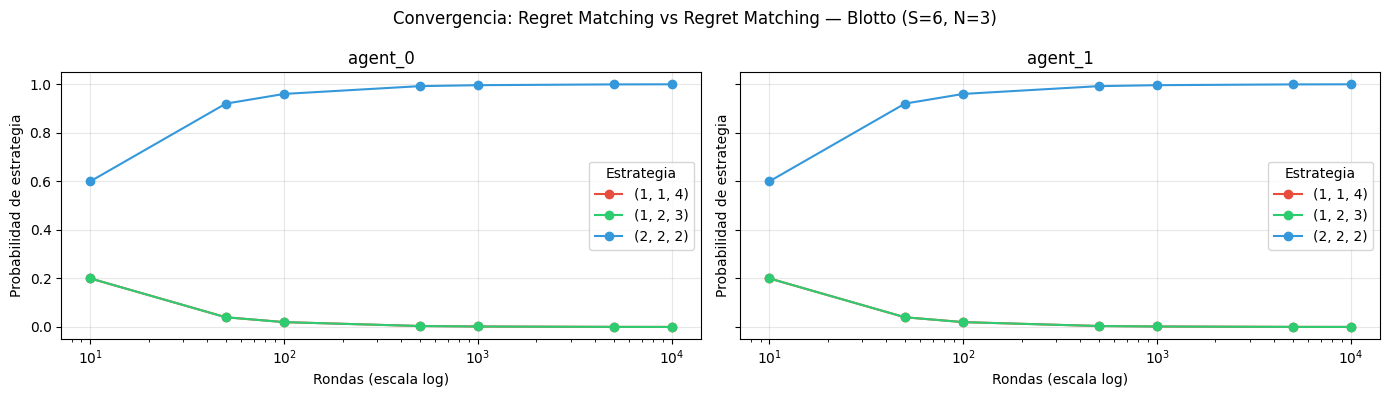

In [26]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Regret Matching — Blotto (S=6, N=3)', g)

### Regret Matching vs Random Agent

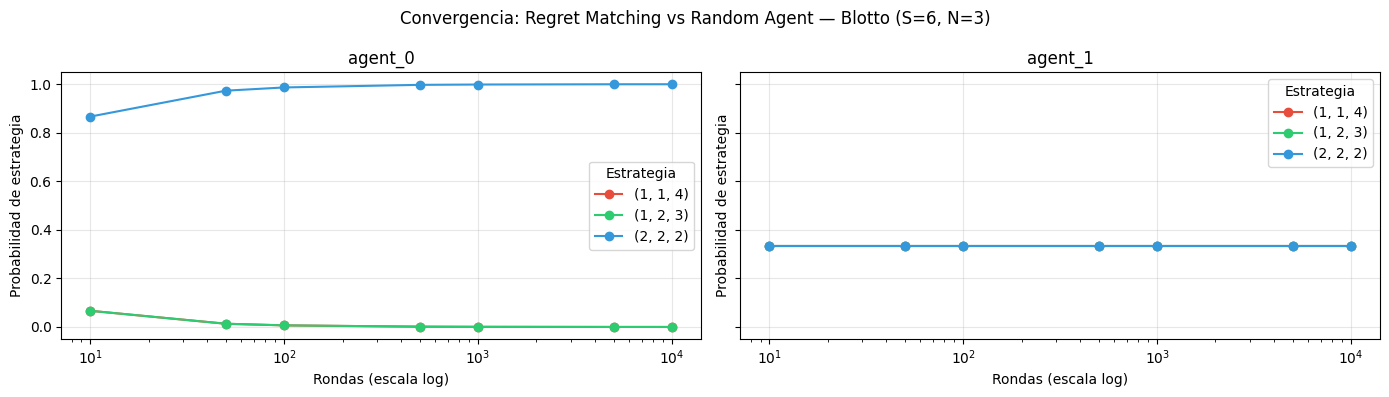

In [27]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Regret Matching vs Random Agent — Blotto (S=6, N=3)', g)

### Fictitious Play vs Fictitious Play

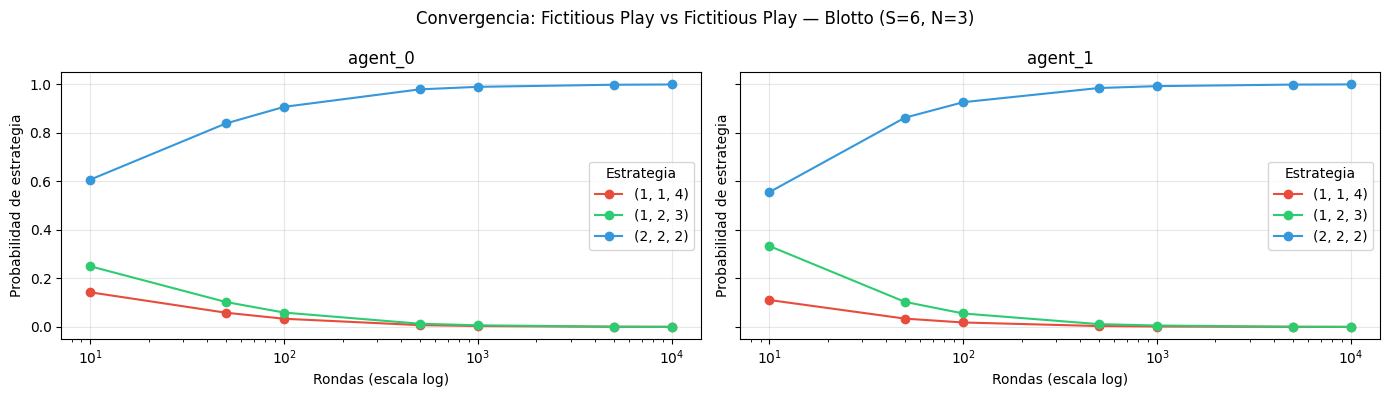

In [28]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Fictitious Play — Blotto (S=6, N=3)', g)

### Fictitious Play vs Random Agent

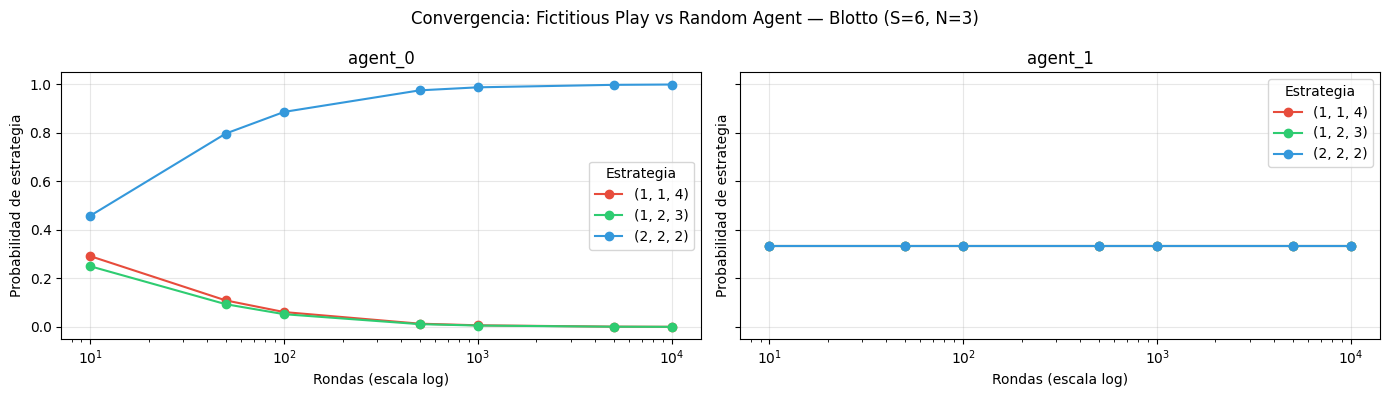

In [29]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Random Agent — Blotto (S=6, N=3)', g)

### Fictitious Play vs Regret Matching

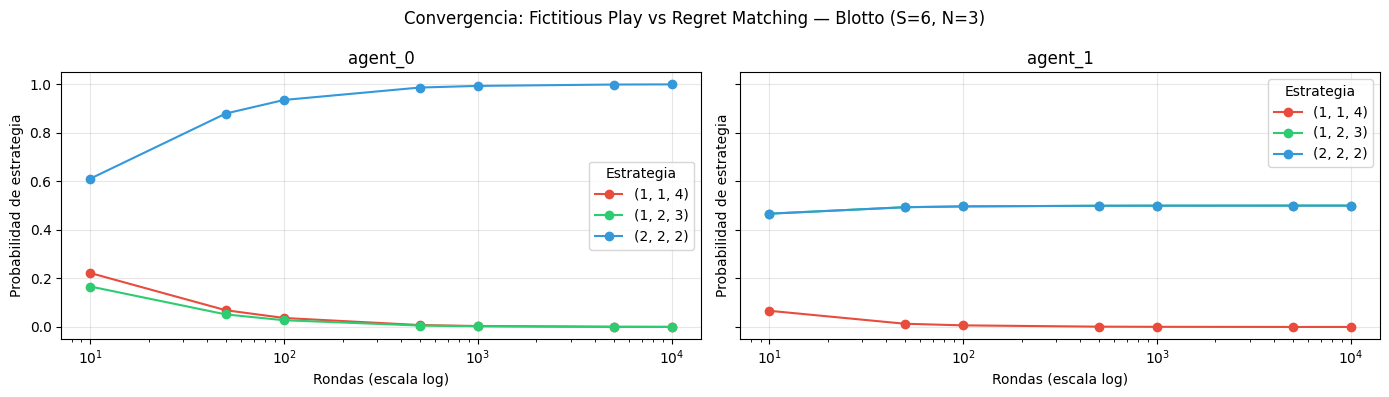

In [30]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RegretMatching(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: Fictitious Play vs Regret Matching — Blotto (S=6, N=3)', g)

### IQL vs Random Agent

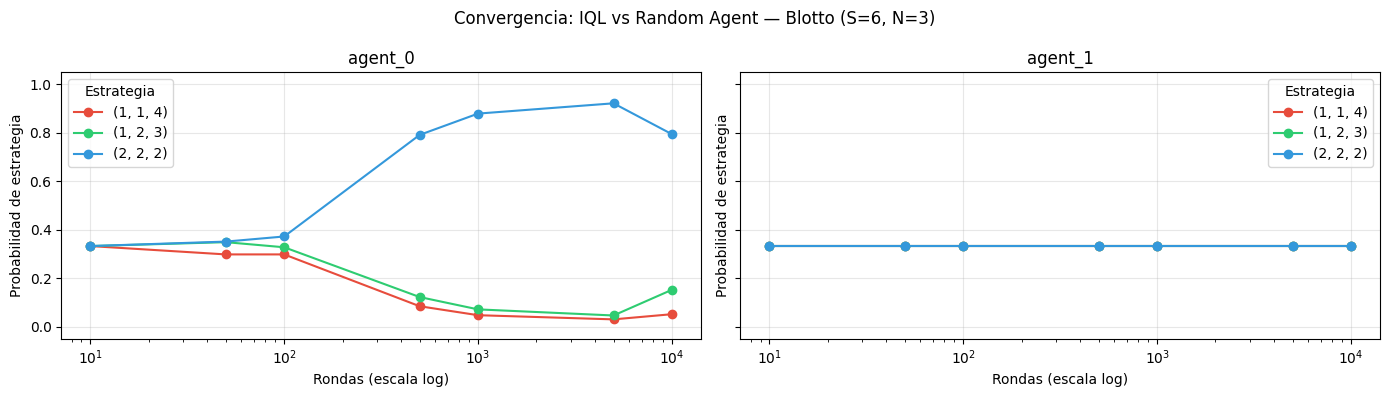

In [31]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs Random Agent — Blotto (S=6, N=3)', g)

### IQL vs IQL

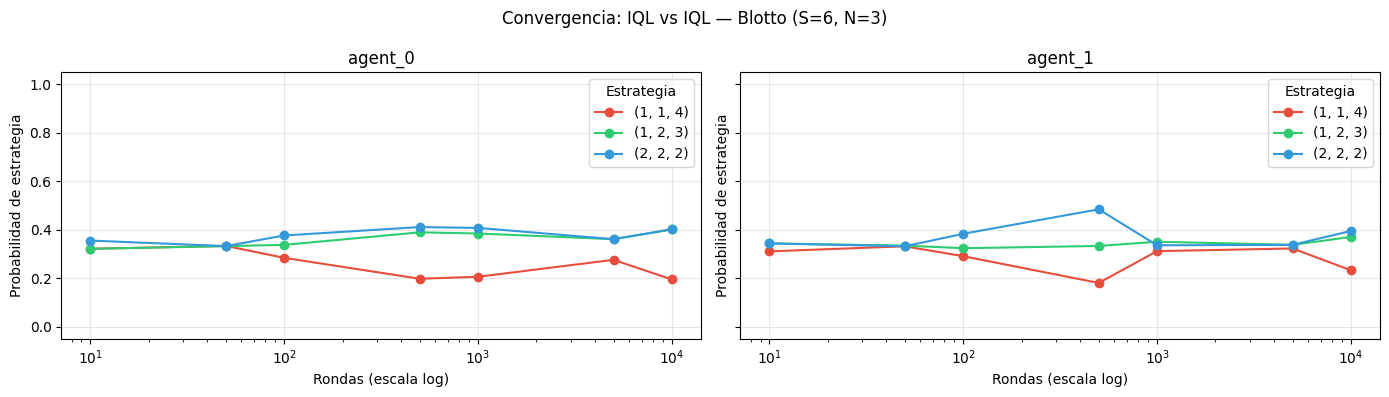

In [32]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs IQL — Blotto (S=6, N=3)', g)

### IQL vs Joint Action Learning AM

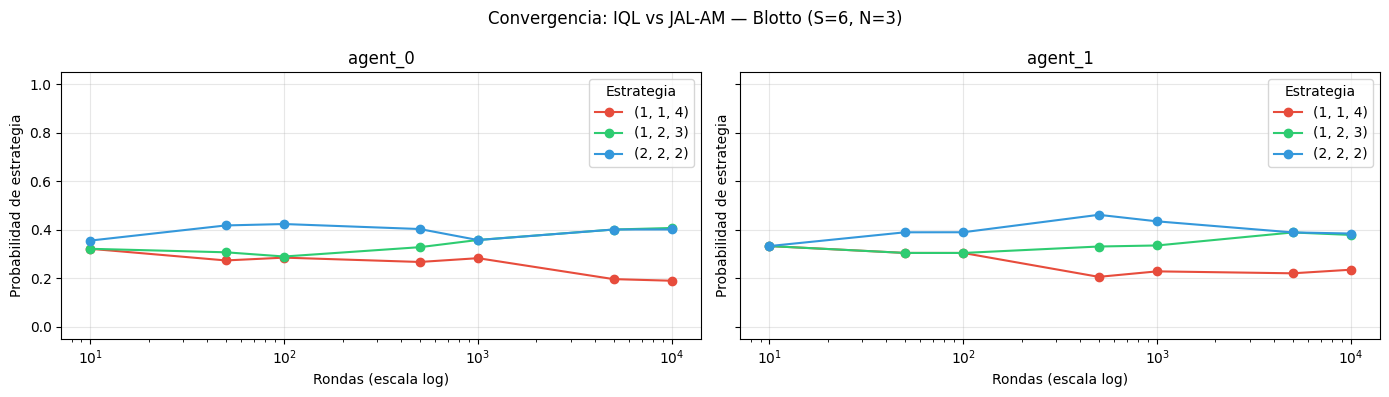

In [33]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: IQL vs JAL-AM — Blotto (S=6, N=3)', g)

### Joint Action Learning AM vs Joint Action Learning AM

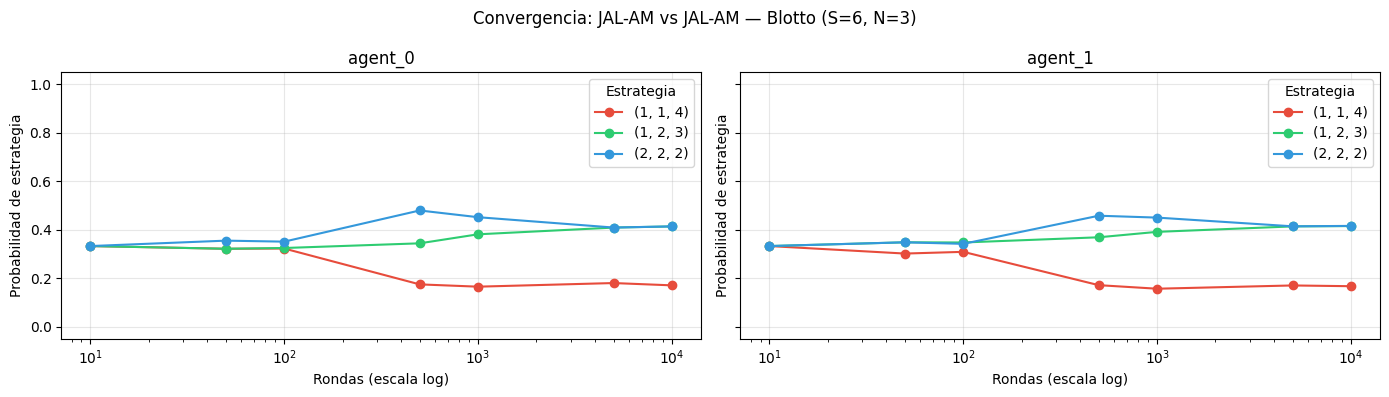

In [34]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia: JAL-AM vs JAL-AM — Blotto (S=6, N=3)', g)

## Análisis de Rewards

Se extiende el análisis con múltiples semillas (`N_SEEDS = 10`) y `N_EPISODES = 10.000` episodios por semilla. Para cada matchup se muestran tres gráficas:

1. **Reward promedio** con banda de confianza (±1 std).
2. **Distancia L1 al EN representativo** $\|\pi - [0, 0.5, 0.5]\|_1$ con IC. La región EN real de Blotto es cualquier mezcla $(0, p, 1-p)$ con $p \in [0,1]$; se usa $[0, 0.5, 0.5]$ como punto de referencia.
3. **P(m₂=(2,2,2)) actual vs. promedio acumulado** (seed 0) — se espera convergencia hacia valores altos.

El reward esperado en cualquier EN es **0** (juego de suma cero).

In [35]:

import os
from utils.experiment import run_experiment_and_plot
from utils.metrics import policy_to_simplex
from utils.constants import COLORS, IQL_KWARGS, JALAM_KWARGS

N_EPISODES    = 10_000
N_SEEDS       = 10
# EN representativo: mezcla equitativa de m₁=(1,2,3) y m₂=(2,2,2)
# La región EN real es cualquier (0, p, 1-p) con p ∈ [0, 1]
NE_BLOTTO     = np.array([0.0, 0.5, 0.5])
# Factory que crea el juego con los parámetros correctos (S=6, N=3)
BLOTTO_FACTORY = lambda: Blotto(S=6, N=3)
os.makedirs('results/Blotto', exist_ok=True)
os.makedirs('figures/Blotto', exist_ok=True)


#### RM vs RM

Saved → results/Blotto/RM_vs_RM/results.json


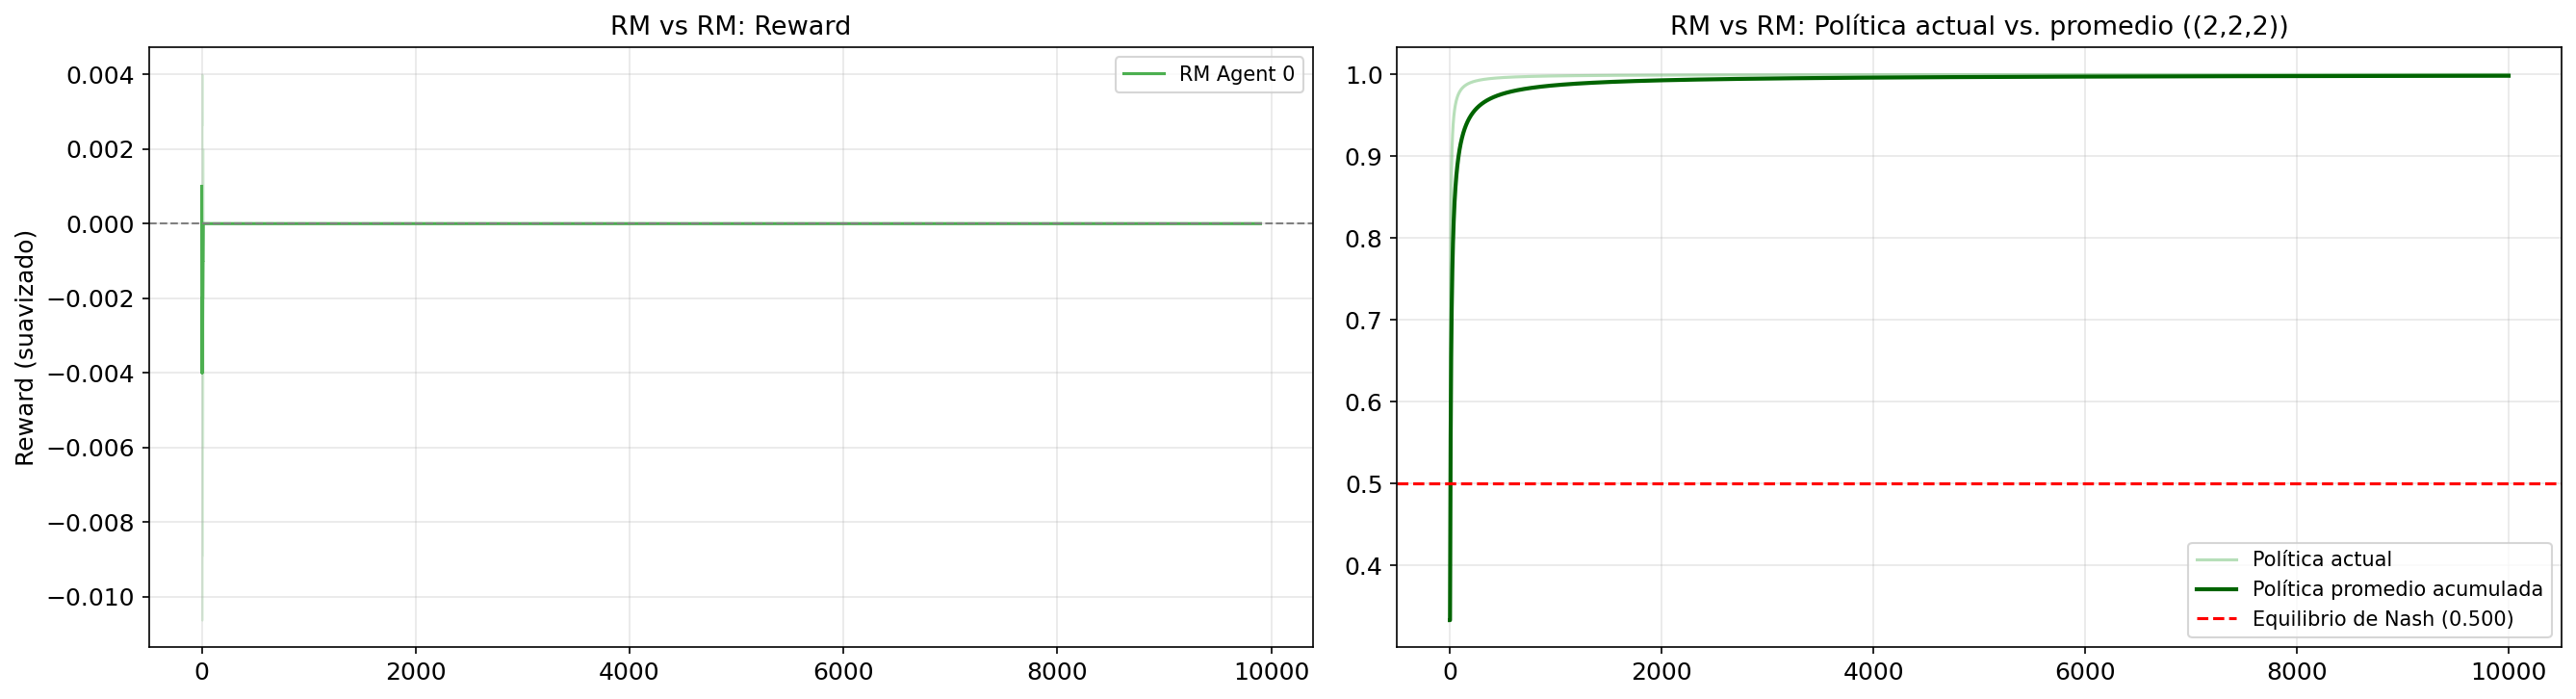

Política final FP (promedio sobre seeds):
  Agent 0: [0. 0. 1.]
  Agent 1: [0.   0.05 0.95]
  Equilibrio de Nash: [0.  0.5 0.5]


In [36]:

rewards_rm, pol0_rm, pol1_rm = run_experiment_and_plot(
    BLOTTO_FACTORY, RegretMatching, RegretMatching,
    NE=NE_BLOTTO, color=COLORS['RM'],
    game_name='Blotto', experiment_name='RM_vs_RM',
    agent0_label='RM', agent1_label='RM',
    action_label='(2,2,2)', action_idx=2,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### FP vs FP

Saved → results/Blotto/FP_vs_FP/results.json


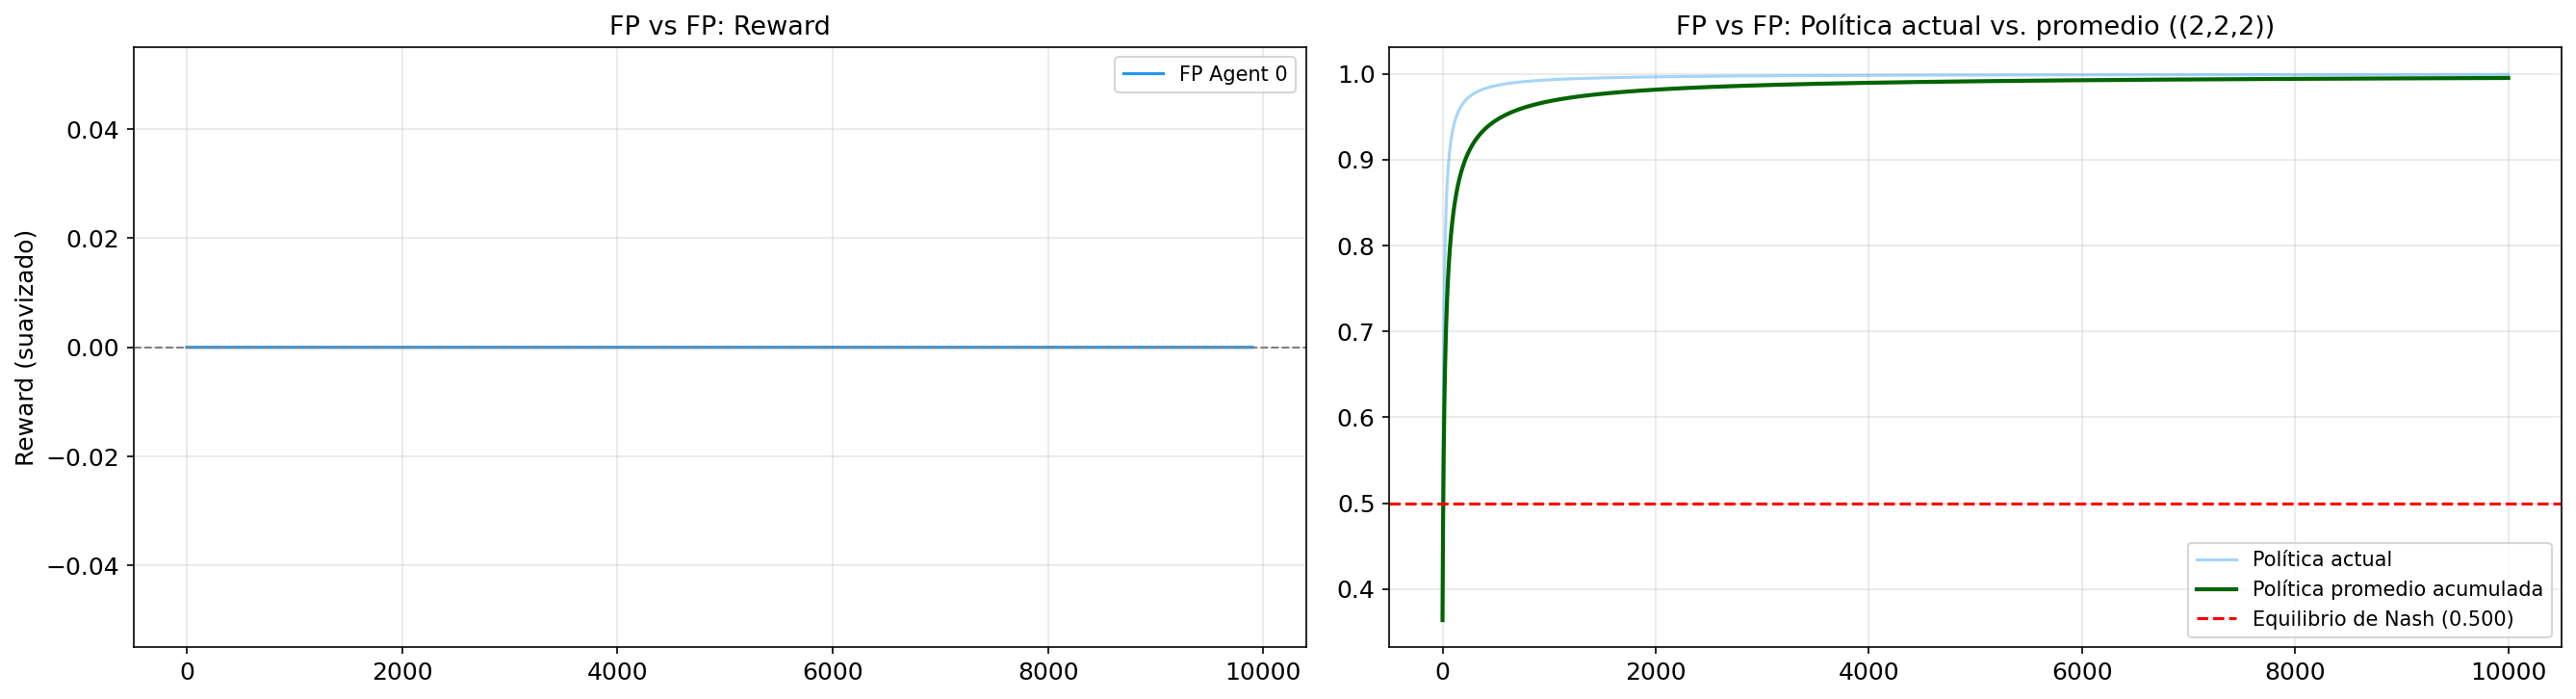

Política final FP (promedio sobre seeds):
  Agent 0: [0.001 0.001 0.999]
  Agent 1: [0.001 0.    0.999]
  Equilibrio de Nash: [0.  0.5 0.5]


In [37]:

rewards_fp, pol0_fp, pol1_fp = run_experiment_and_plot(
    BLOTTO_FACTORY, FictitiousPlay, FictitiousPlay,
    NE=NE_BLOTTO, color=COLORS['FP'],
    game_name='Blotto', experiment_name='FP_vs_FP',
    agent0_label='FP', agent1_label='FP',
    action_label='(2,2,2)', action_idx=2,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### IQL vs IQL

Saved → results/Blotto/IQL_vs_IQL/results.json


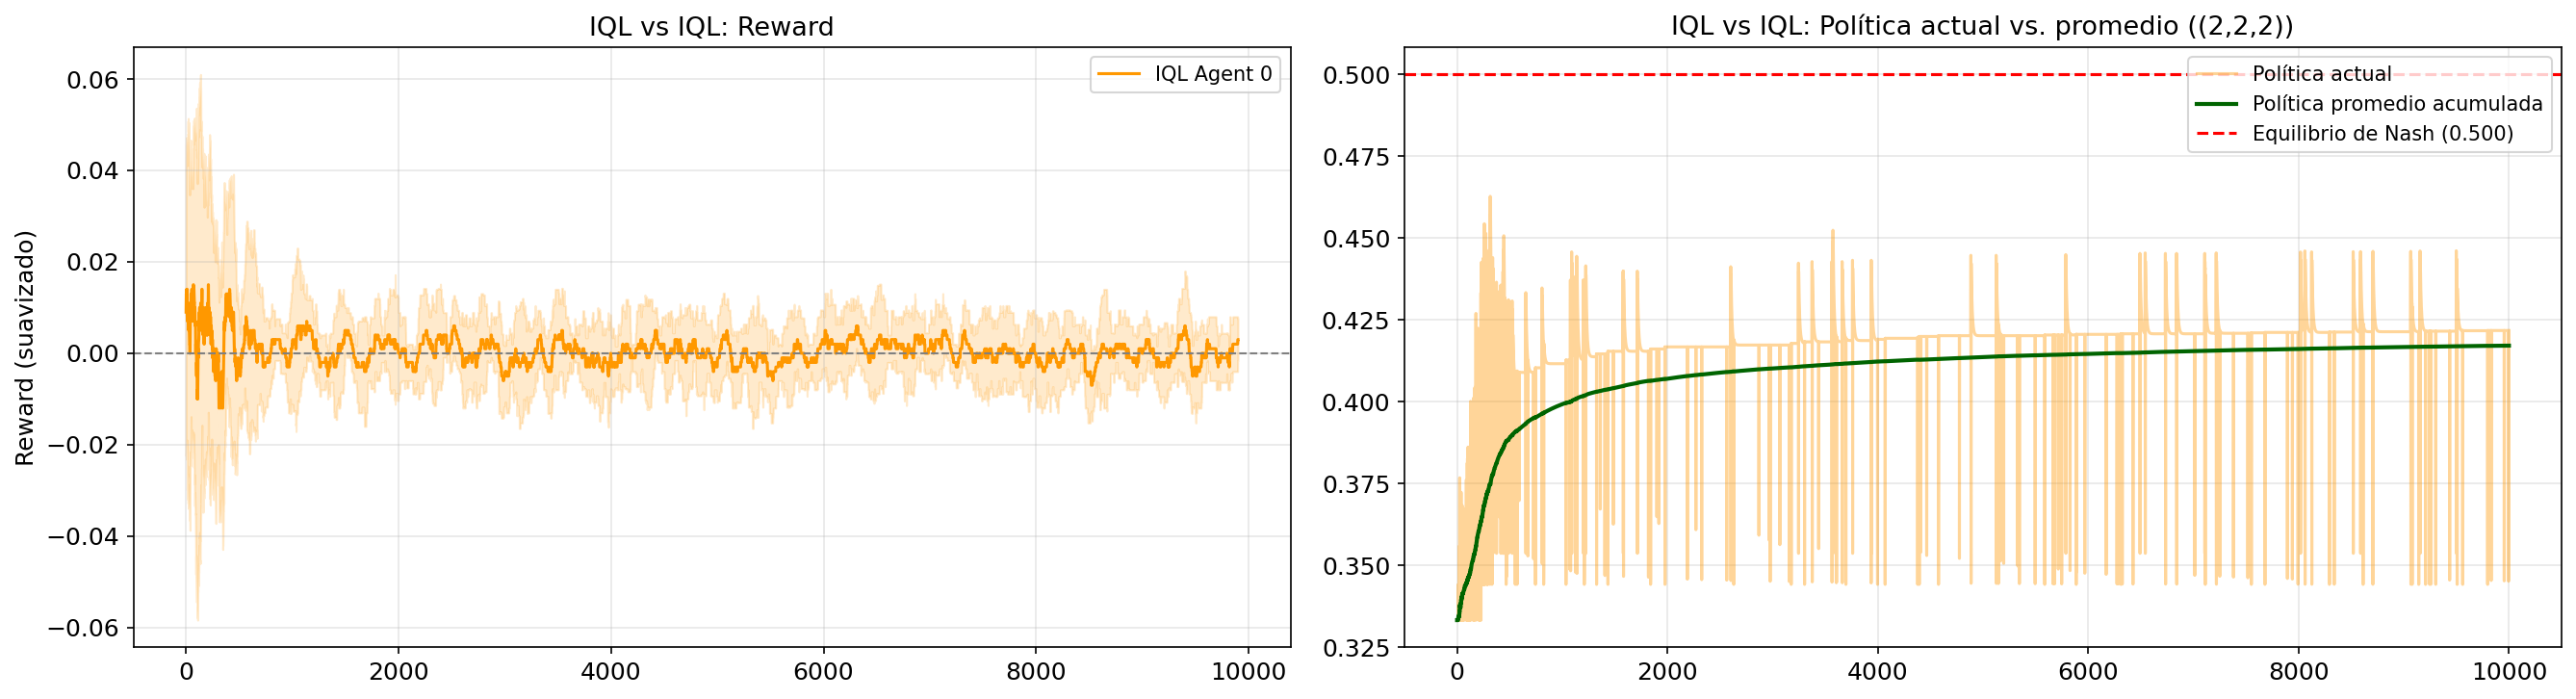

Política final FP (promedio sobre seeds):
  Agent 0: [0.159 0.419 0.421]
  Agent 1: [0.158 0.42  0.422]
  Equilibrio de Nash: [0.  0.5 0.5]


In [38]:

rewards_iql, pol0_iql, pol1_iql = run_experiment_and_plot(
    BLOTTO_FACTORY, IndependentQLearning, IndependentQLearning,
    NE=NE_BLOTTO, color=COLORS['IQL'],
    game_name='Blotto', experiment_name='IQL_vs_IQL',
    agent0_label='IQL', agent1_label='IQL',
    action_label='(2,2,2)', action_idx=2,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=IQL_KWARGS, agent1_kwargs=IQL_KWARGS,
)


#### JAL-AM vs JAL-AM

Saved → results/Blotto/JALAM_vs_JALAM/results.json


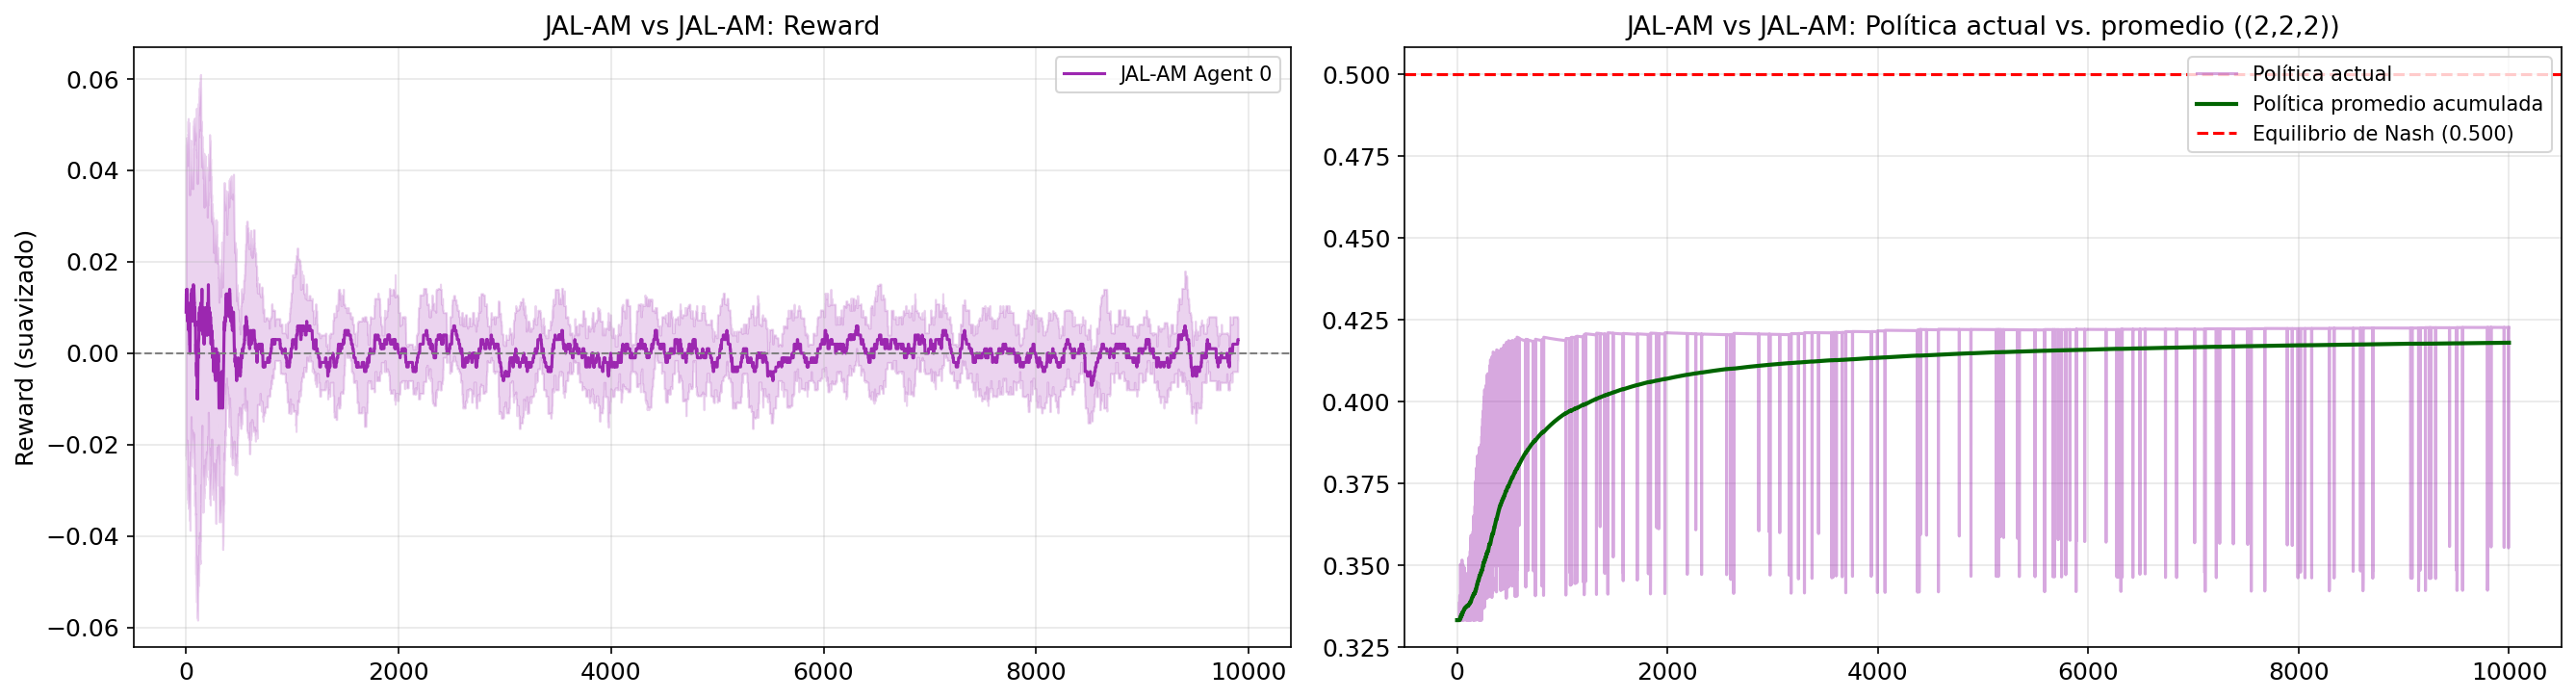

Política final FP (promedio sobre seeds):
  Agent 0: [0.159 0.419 0.422]
  Agent 1: [0.159 0.419 0.422]
  Equilibrio de Nash: [0.  0.5 0.5]


In [39]:

rewards_jal, pol0_jal, pol1_jal = run_experiment_and_plot(
    BLOTTO_FACTORY, JointActionLearningAM, JointActionLearningAM,
    NE=NE_BLOTTO, color=COLORS['JAL-AM'],
    game_name='Blotto', experiment_name='JALAM_vs_JALAM',
    agent0_label='JAL-AM', agent1_label='JAL-AM',
    action_label='(2,2,2)', action_idx=2,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=JALAM_KWARGS, agent1_kwargs=JALAM_KWARGS,
)


#### FP vs RM

Saved → results/Blotto/FP_vs_RM/results.json


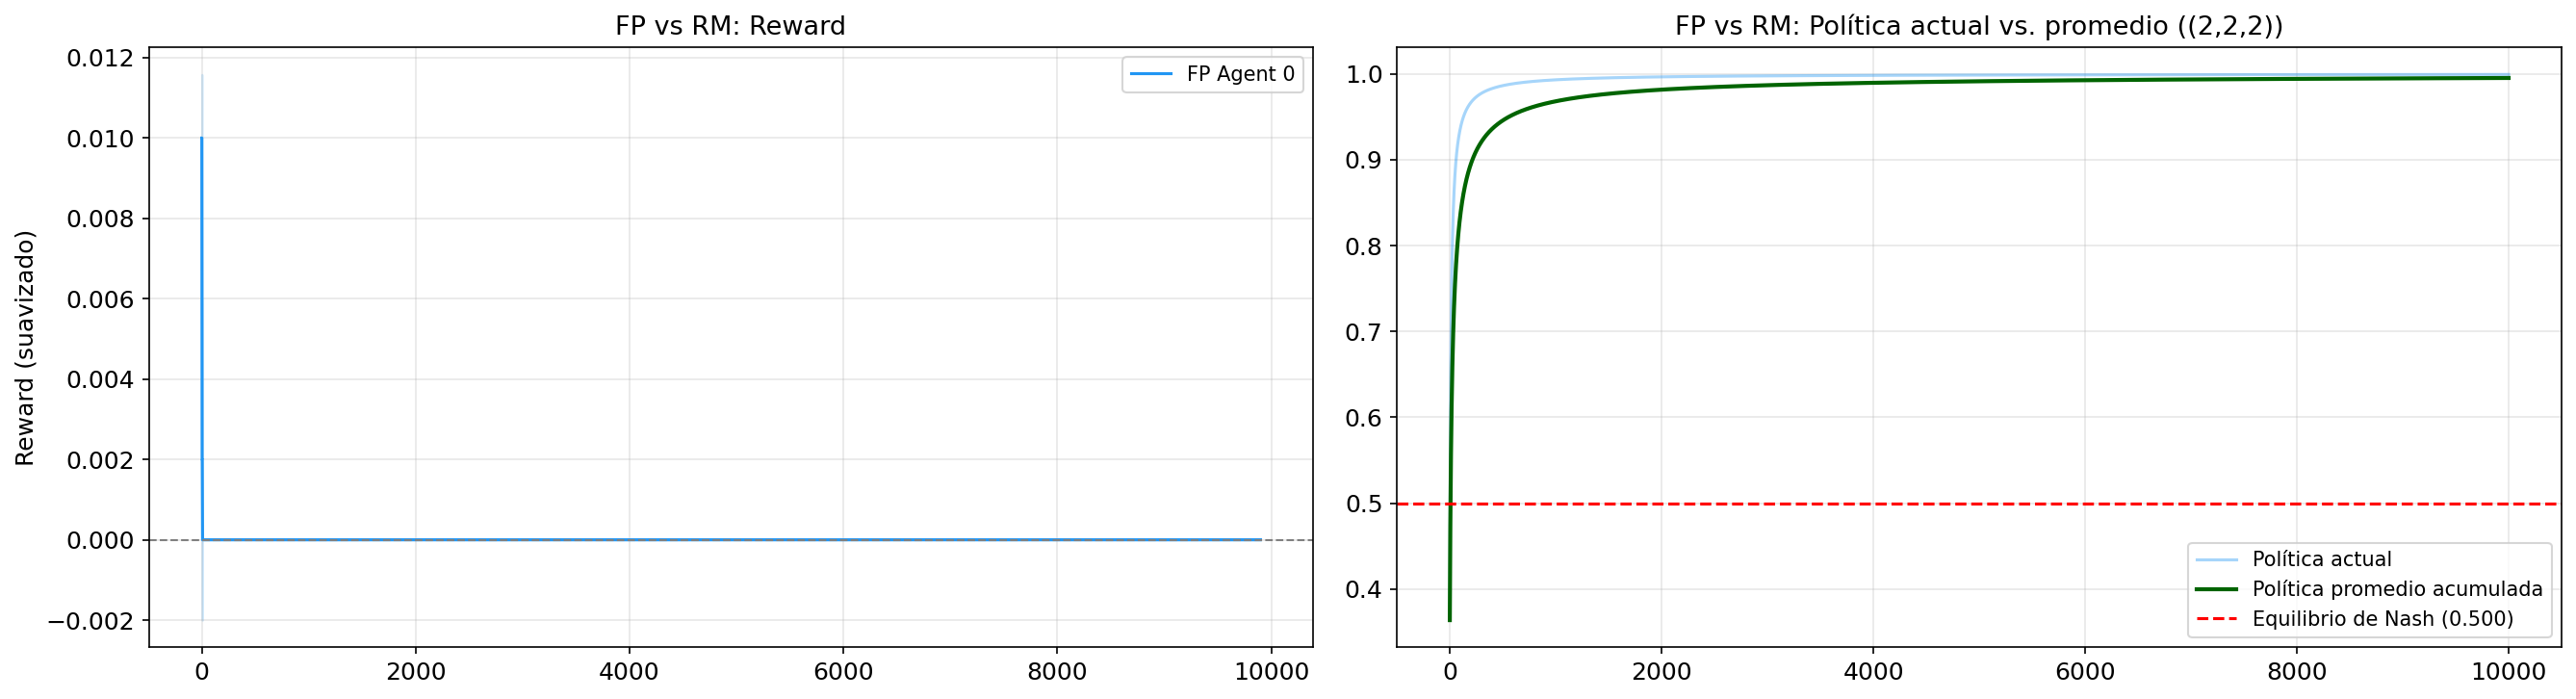

Política final FP (promedio sobre seeds):
  Agent 0: [0.001 0.001 0.999]
  Agent 1: [0.  0.5 0.5]
  Equilibrio de Nash: [0.  0.5 0.5]


In [40]:

rewards_fp_rm, pol0_fp_rm, pol1_fp_rm = run_experiment_and_plot(
    BLOTTO_FACTORY, FictitiousPlay, RegretMatching,
    NE=NE_BLOTTO, color=COLORS['FP'], color1=COLORS['RM'],
    game_name='Blotto', experiment_name='FP_vs_RM',
    agent0_label='FP', agent1_label='RM',
    action_label='(2,2,2)', action_idx=2,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


## Trayectoria de Política en el Simplex

Dado que Blotto tiene exactamente **3 estrategias puras**, la política de cada agente es un punto en el **simplex 2D** (triángulo equilátero):

- Vértice inferior izquierdo: **m₀ = (1,1,4)** — estrategia débilmente dominada.
- Vértice inferior derecho: **m₁ = (1,2,3)**.
- Vértice superior: **m₂ = (2,2,2)**.

La **región EN** (segmento rojo) es el borde entre m₁ y m₂: cualquier mezcla con P(m₀)=0 es un equilibrio de Nash. La trayectoria va del verde (inicio) al azul (final); la opacidad crece con el tiempo.

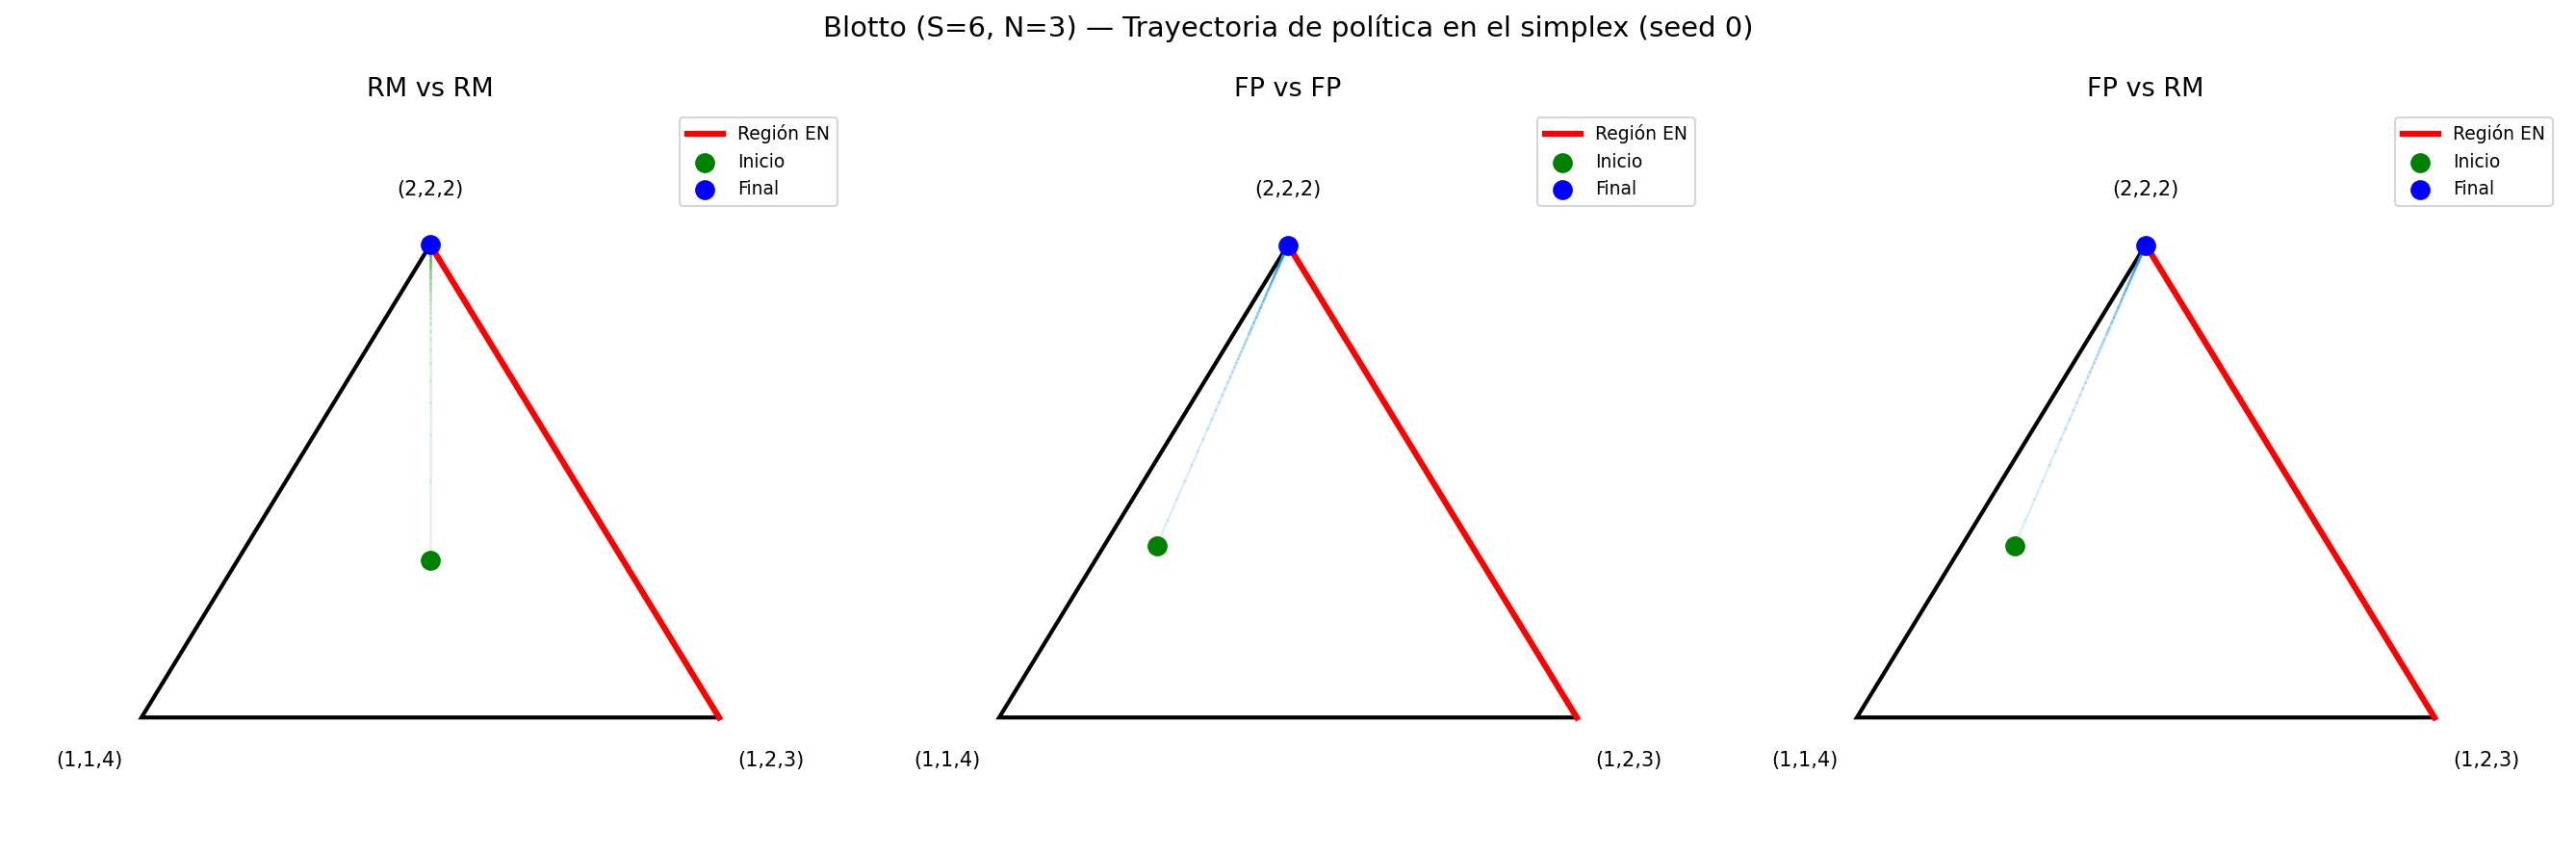

In [43]:

def draw_blotto_simplex(ax, action_labels=('(1,1,4)', '(1,2,3)', '(2,2,2)')):
    """Dibuja el simplex de Blotto. La región EN es el segmento entre m₁ y m₂."""
    v = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
    tri = plt.Polygon(v, fill=False, edgecolor='black', lw=2)
    ax.add_patch(tri)
    offset = 0.09
    ax.text(v[0, 0] - offset, v[0, 1] - offset, action_labels[0], ha='center', fontsize=10)
    ax.text(v[1, 0] + offset, v[1, 1] - offset, action_labels[1], ha='center', fontsize=10)
    ax.text(v[2, 0],           v[2, 1] + offset, action_labels[2], ha='center', fontsize=10)
    ax.plot([v[1, 0], v[2, 0]], [v[1, 1], v[2, 1]],
            'r-', lw=3, zorder=5, label='Región EN')
    ax.set_xlim(-0.22, 1.22)
    ax.set_ylim(-0.22, np.sqrt(3) / 2 + 0.25)
    ax.axis('off')


blotto_labels = ('(1,1,4)', '(1,2,3)', '(2,2,2)')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Blotto (S=6, N=3) — Trayectoria de política en el simplex (seed 0)', fontsize=14)

for ax, (pol, name, color) in zip(axes, [
    (pol0_rm,    'RM vs RM', COLORS['RM']),
    (pol0_fp,    'FP vs FP', COLORS['FP']),
    (pol0_fp_rm, 'FP vs RM', COLORS['FP']),
]):
    draw_blotto_simplex(ax, blotto_labels)
    traj = policy_to_simplex(pol[0])   # seed 0, shape (n_episodes, 2)
    n = len(traj)
    # Índice 0 explícito + muestreo logarítmico para ver la dinámica temprana
    idxs = np.unique(np.concatenate([[0], np.round(np.logspace(0, np.log10(n - 1), 200)).astype(int).clip(0, n - 1)]))
    sampled = traj[idxs]
    for k in range(len(sampled) - 1):
        alpha = 0.15 + 0.85 * (k / len(sampled))
        ax.plot(sampled[k:k + 2, 0], sampled[k:k + 2, 1], color=color, alpha=alpha, lw=1.2)
    ax.scatter(*traj[0],  c='green', s=80, zorder=7, label='Inicio')
    ax.scatter(*traj[-1], c='blue',  s=80, zorder=7, label='Final')
    ax.set_title(name, fontsize=13)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('figures/Blotto/simplex_trajectory.png', dpi=150)
plt.show()


### Conclusiones
- Se encontraron dos equilibrios de Nash en $(2, 2, 2)$ y $(1,2,3)$, todos los agentes salvo el Random, tienen a descartar la estrategia dominada $(1,1,4)$
- Analizando la performance por agente, tenemos que:
    - **Ficticious** y **Regret Matching** son los que aprenden más rapido a encontrar una estrategia debilmente dominante.
    - **Random** mitiga entre las estrategias pero sin aprender
    - **JAL-AM** aprende más lento que  **Ficticious** y **Regret Matching** pero arroja resultados válidos, eligiendo con mayor frecuencia a las estrategias débilmente dominantes.
    - **IQL** fue sumamente inestable contra **Random**, en un caso particular en donde **Random** eligió a una de las estrategias débilmente dominantes. Jugando contra él mismo y contra  **JAL-AM** fue un poco más estable. 
    